# fetch some data

In [13]:
%load_ext autoreload
%autoreload 2

# transfer ds to nhi-gpu
import pandas as pd
import json # For dealing with metadata
import os # For file level operations
from datafed.CommandLib import API
df_api = API()

ls_resp = df_api.collectionItemsList('c/391027993', count=50)
print(ls_resp)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Exception: Timeout waiting for server connection.

In [3]:
dv_resp = df_api.dataView('d/399592342')
# metadata = json.loads(dv_resp[0].data[0].metadata)
# print(metadata)

id_index = dv_resp[0].data[0].id
get_resp = df_api.dataGet(id_index, '/mnt/c/Users/yig319/Dropbox (LU Student)/plume_dynamic_analysis/datasets/', orig_fname=True, wait=True)
get_resp

(task {
   id: "task/480700604"
   type: TT_DATA_GET
   status: TS_FAILED
   client: "u/yig319"
   step: 1
   steps: 3
   msg: "permission denied"
   ct: 1689708520
   ut: 1689708527
   source: "d/399592342"
   dest: "5c48764e-bc4f-11ed-98a1-cf2723108f0c/mnt/c/Users/yig319/Dropbox (LU Student)/plume_dynamic_analysis/datasets"
 },
 'TaskDataReply')

In [3]:
dv_resp = df_api.dataView('d/399595765')
# metadata = json.loads(dv_resp[0].data[0].metadata)
# print(metadata)

id_index = dv_resp[0].data[0].id
get_resp = df_api.dataGet(id_index, '../datasets/', orig_fname=True, wait=True)
get_resp

(task {
   id: "task/480700012"
   type: TT_DATA_GET
   status: TS_FAILED
   client: "u/yig319"
   step: 1
   steps: 3
   msg: "permission denied"
   ct: 1689708270
   ut: 1689708276
   source: "d/399595765"
   dest: "5c48764e-bc4f-11ed-98a1-cf2723108f0c/home/yichen/plume_dynamic_analysis/notebooks"
 },
 'TaskDataReply')

In [4]:
dv_resp = df_api.dataView('d/398116872')
# metadata = json.loads(dv_resp[0].data[0].metadata)
# print(metadata)

id_index = dv_resp[0].data[0].id
get_resp = df_api.dataGet(id_index, '../datasets/', orig_fname=True, wait=True)
get_resp

(task {
   id: "task/480700080"
   type: TT_DATA_GET
   status: TS_FAILED
   client: "u/yig319"
   step: 1
   steps: 3
   msg: "permission denied"
   ct: 1689708278
   ut: 1689708284
   source: "d/398116872"
   dest: "5c48764e-bc4f-11ed-98a1-cf2723108f0c/home/yichen/plume_dynamic_analysis/notebooks"
 },
 'TaskDataReply')

# plot

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import sys
sys.path.append('../src/')
from utils import show_h5_dataset_name
from utils import load_h5_examples
from utils import show_images
from PlumeEvaluation import PlumeMetrics
from PlumeEvaluation import plot_metrics
from PlumeEvaluation import plot_metrics_heatmap

def process_func(images):
    '''
    An example process function to preprocess images before conducting following steps

    :param images: images to preprocess
    :type images: np.array
    '''

    images = images[np.random.randint(0, images.shape[0])]
    return images

def plot_metrics_all_steps(ds_path, class_name, ds_name, condition, visualize=False):
    plumes = load_h5_examples(ds_path, class_name, ds_name, process_func, show=False)

    m = PlumeMetrics(plumes, condition)

    metrics_np = m.get_metrics()
    metrics_df = m.to_df(metrics_np)
    print(metrics_df.sample(n=5))

    if visualize:
        show_images(np.mean(plumes, axis=0), img_per_row=10)
        plot_metrics(metrics_df, sort_by='growth_index')
        plot_metrics_heatmap(metrics_df, frame_range=(8, 46))
    
    return metrics_df

In [2]:
ds_path = '../datasets/plume_dynamic_SRO/set_1-YG028-030/plumes/YG028_Yichen_Guo_06012022.h5'
class_name = 'PLD_Plumes'
show_h5_dataset_name(ds_path, class_name)

<KeysViewHDF5 ['1-SrRuO3', '1-SrRuO3_Pre']>


In [3]:
ds_name = '1-SrRuO3'
condition = '100mj-700c-200mtorr-10hz-growth_1'
df_1 = plot_metrics_all_steps(ds_path, class_name, ds_name, condition)

                               condition             metric  growth_index  \
54738  100mj-700c-200mtorr-10hz-growth_1       eccentricity            42   
24479  100mj-700c-200mtorr-10hz-growth_1  axis_minor_length            26   
52660  100mj-700c-200mtorr-10hz-growth_1       eccentricity            26   
18672  100mj-700c-200mtorr-10hz-growth_1  axis_major_length            35   
3226   100mj-700c-200mtorr-10hz-growth_1               area            25   

       time_step          a.u.  
54738         82      0.000000  
24479         31    167.481186  
52660         52      0.000000  
18672        112      0.000000  
3226          26  28946.000000  


In [4]:
ds_path = '../datasets/plume_dynamic_SRO/set_1-YG028-030/plumes/YG029_Yichen_Guo_06012022.h5'
class_name = 'PLD_Plumes'
show_h5_dataset_name(ds_path, class_name)

<KeysViewHDF5 ['1-SrRuO3', '1-SrRuO3_Pre']>


In [5]:
ds_name = '1-SrRuO3'
condition = '100mj-700c-200mtorr-10hz-growth_2'
df_2 = plot_metrics_all_steps(ds_path, class_name, ds_name, condition)

                               condition       metric  growth_index  \
2783   100mj-700c-200mtorr-10hz-growth_2         area            21   
37430  100mj-700c-200mtorr-10hz-growth_2   centroid-2            17   
8537   100mj-700c-200mtorr-10hz-growth_2  area_filled            11   
164    100mj-700c-200mtorr-10hz-growth_2         area             1   
28379  100mj-700c-200mtorr-10hz-growth_2   centroid-1             1   

       time_step     a.u.  
2783          95      0.0  
37430         54      0.0  
8537          89      0.0  
164           36  16294.0  
28379         91      0.0  


In [6]:
ds_path = '../datasets/plume_dynamic_SRO/set_1-YG028-030/plumes/YG030_Yichen_Guo_06012022.h5'
class_name = 'PLD_Plumes'
show_h5_dataset_name(ds_path, class_name)

<KeysViewHDF5 ['1-SrRuO3', '1-SrRuO3_Pre']>


In [7]:
ds_name = '1-SrRuO3'
condition = '100mj-700c-200mtorr-10hz-growth_3'
df_3 = plot_metrics_all_steps(ds_path, class_name, ds_name, condition)

                               condition      metric  growth_index  time_step  \
40988  100mj-700c-200mtorr-10hz-growth_3  centroid-2            45         28   
57663  100mj-700c-200mtorr-10hz-growth_3   perimeter            10         63   
32966  100mj-700c-200mtorr-10hz-growth_3  centroid-1            37         70   
71986  100mj-700c-200mtorr-10hz-growth_3    velocity            12         50   
4170   100mj-700c-200mtorr-10hz-growth_3        area            32         74   

            a.u.  
40988  90.780968  
57663   0.000000  
32966   0.000000  
71986   0.000000  
4170    0.000000  


In [8]:
df_1[df_1['time_step']<80]

,condition,metric,growth_index,time_step,a.u.
0,100mj-700c-200mtorr-10hz-growth_1,area,0,0,0.0
1,100mj-700c-200mtorr-10hz-growth_1,area,0,1,0.0
2,100mj-700c-200mtorr-10hz-growth_1,area,0,2,0.0
3,100mj-700c-200mtorr-10hz-growth_1,area,0,3,0.0
4,100mj-700c-200mtorr-10hz-growth_1,area,0,4,0.0
...,...,...,...,...,...
77387,100mj-700c-200mtorr-10hz-growth_1,velocity,54,75,0.0
77388,100mj-700c-200mtorr-10hz-growth_1,velocity,54,76,0.0
77389,100mj-700c-200mtorr-10hz-growth_1,velocity,54,77,0.0
77390,100mj-700c-200mtorr-10hz-growth_1,velocity,54,78,0.0


<Figure size 1200x800 with 0 Axes>

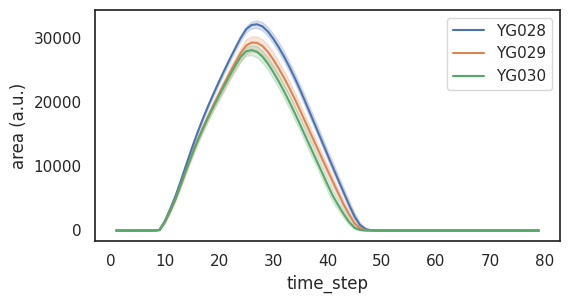

<Figure size 1200x800 with 0 Axes>

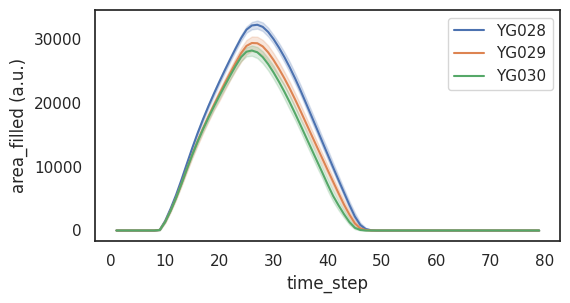

<Figure size 1200x800 with 0 Axes>

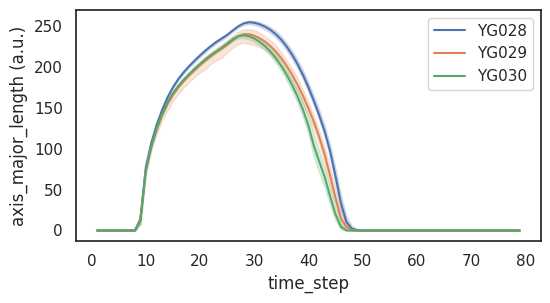

<Figure size 1200x800 with 0 Axes>

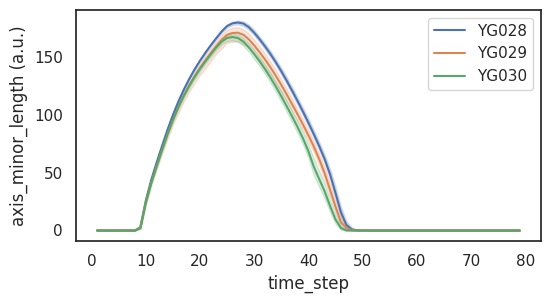

<Figure size 1200x800 with 0 Axes>

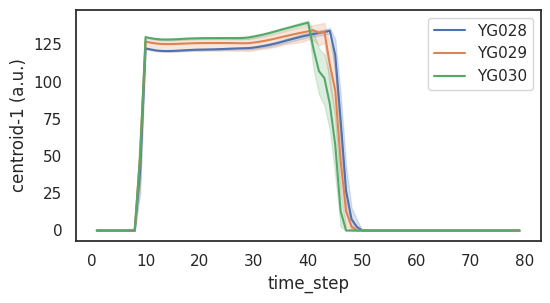

<Figure size 1200x800 with 0 Axes>

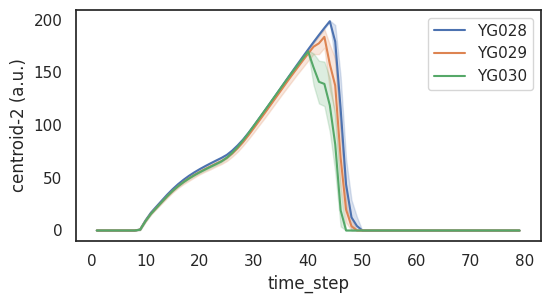

<Figure size 1200x800 with 0 Axes>

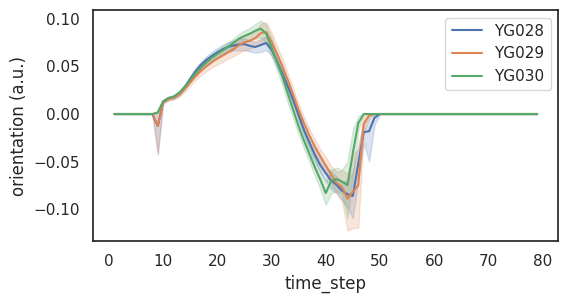

<Figure size 1200x800 with 0 Axes>

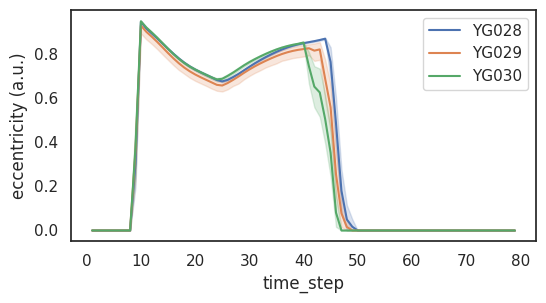

<Figure size 1200x800 with 0 Axes>

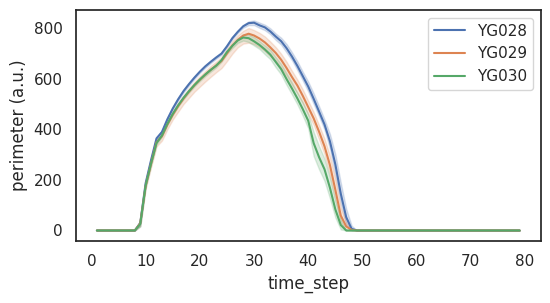

<Figure size 1200x800 with 0 Axes>

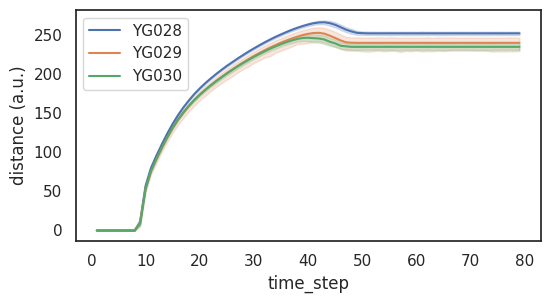

<Figure size 1200x800 with 0 Axes>

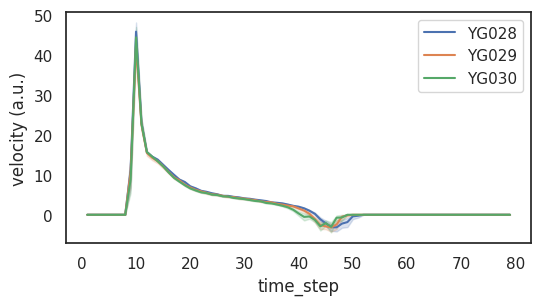

,condition,metric,growth_index,time_step,a.u.
1,100mj-700c-200mtorr-10hz-growth_1,area,0,1,0.0
2,100mj-700c-200mtorr-10hz-growth_1,area,0,2,0.0
3,100mj-700c-200mtorr-10hz-growth_1,area,0,3,0.0
4,100mj-700c-200mtorr-10hz-growth_1,area,0,4,0.0
5,100mj-700c-200mtorr-10hz-growth_1,area,0,5,0.0
...,...,...,...,...,...
232267,100mj-700c-200mtorr-10hz-growth_3,velocity,54,75,0.0
232268,100mj-700c-200mtorr-10hz-growth_3,velocity,54,76,0.0
232269,100mj-700c-200mtorr-10hz-growth_3,velocity,54,77,0.0
232270,100mj-700c-200mtorr-10hz-growth_3,velocity,54,78,0.0


In [9]:
import pandas as pd

df_all = pd.concat([df_1, df_2, df_3], ignore_index=True)
plot_metrics(df_all, sort_by='condition', ranges=(0,80), legend_title=None, custom_labels=['YG028', 'YG029', 'YG030'])

# upload notebook to dataset

In [14]:
import pandas as pd
import json # For dealing with metadata
import os # For file level operations
from datafed.CommandLib import API

file_name = '06012022-plume_YG028-30.ipynb'
file_path = %pwd
print(file_path+'/'+file_name)

df_api = API()
dc_resp = df_api.dataCreate(file_name,
                            parent_id='c/398047791', # parent collection
                           )

rec_id = dc_resp[0].data[0].id
put_resp = df_api.dataPut(rec_id, # record id
                          file_path+'/'+file_name,
                          wait=True  # Waitcas until transfer completes.
                          )
put_resp

/scratch/yichen/notebooks/PLD_Workflow/06012022-plume_YG028-30.ipynb


(task {
   id: "task/398483024"
   type: TT_DATA_PUT
   status: TS_SUCCEEDED
   client: "u/yig319"
   step: 3
   steps: 4
   msg: "Finished"
   ct: 1654658871
   ut: 1654658877
   source: "lehigh#nhi-gpu/scratch/yichen/notebooks/PLD_Workflow/06012022-plume_YG028-30.ipynb"
   dest: "d/398483018"
 },
 'TaskDataReply')

In [ ]:
# fetch some data

# transfer ds to nhi-gpu
import pandas as pd
import json # For dealing with metadata
import os # For file level operations
from datafed.CommandLib import API
df_api = API()

ls_resp = df_api.collectionItemsList('c/391027993', count=50)
print(ls_resp)

dv_resp = df_api.dataView('d/397976169')
metadata = json.loads(dv_resp[0].data[0].metadata)
print(metadata)

id_index = dv_resp[0].data[0].id
get_resp = df_api.dataGet(id_index, '/scratch/yichen/pld_plumes/', orig_fname=True, wait=True)
get_resp

dv_resp = df_api.dataView('d/397967213')
metadata = json.loads(dv_resp[0].data[0].metadata)
print(metadata)

id_index = dv_resp[0].data[0].id
get_resp = df_api.dataGet(id_index, '/scratch/yichen/pld_plumes/', orig_fname=True, wait=True)
get_resp

dv_resp = df_api.dataView('d/397958247')
metadata = json.loads(dv_resp[0].data[0].metadata)
print(metadata)

id_index = dv_resp[0].data[0].id
get_resp = df_api.dataGet(id_index, '/scratch/yichen/pld_plumes/', orig_fname=True, wait=True)
get_resp

# plot

import numpy as np
import sys
sys.path.append('./PLD_Workflow/')
from utils import show_h5_dataset_name
from utils import load_h5_examples
from utils import show_images
from PlumeEvaluation import PlumeMetrics
from PlumeEvaluation import plot_metrics
from PlumeEvaluation import plot_metrics_heatmap

def process_func(images):
    '''
    An example process function to preprocess images before conducting following steps

    :param images: images to preprocess
    :type images: np.array
    '''

    images = images[np.random.randint(0, images.shape[0])]
    return images

def plot_metrics_all_steps(ds_path, class_name, ds_name, condition):
    plumes = load_h5_examples(ds_path, class_name, ds_name, process_func, show=False)
    show_images(np.mean(plumes, axis=0), img_per_row=10)

    m = PlumeMetrics(plumes, condition)

    metrics_np = m.get_metrics()
    metrics_df = m.to_df(metrics_np)
    print(metrics_df.sample(n=5))

    plot_metrics(metrics_df, sort_by='growth_index')
    plot_metrics_heatmap(metrics_df, frame_range=(8, 46))
    
    return metrics_df



ds_path = '/scratch/yichen/pld_plumes/YG028_Yichen_Guo_06012022.h5'
class_name = 'PLD_Plumes'
show_h5_dataset_name(ds_path, class_name)

ds_name = '1-SrRuO3'
condition = '100mj-700c-200mtorr-10hz-growth_1'
df_1 = plot_metrics_all_steps(ds_path, class_name, ds_name, condition)

df_1.head()

ds_path = '/scratch/yichen/pld_plumes/YG029_Yichen_Guo_06012022.h5'
class_name = 'PLD_Plumes'
show_h5_dataset_name(ds_path, class_name)

ds_name = '1-SrRuO3'
condition = '100mj-700c-200mtorr-10hz-growth_2'
df_2 = plot_metrics_all_steps(ds_path, class_name, ds_name, condition)



ds_path = '/scratch/yichen/pld_plumes/YG030_Yichen_Guo_06012022.h5'
class_name = 'PLD_Plumes'
show_h5_dataset_name(ds_path, class_name)

ds_name = '1-SrRuO3'
condition = '100mj-700c-200mtorr-10hz-growth_3'
df_3 = plot_metrics_all_steps(ds_path, class_name, ds_name, condition)



import pandas as pd

df_all = pd.concat([df_1, df_2, df_3], ignore_index=True)
plot_metrics(df_all, sort_by='condition')

# upload notebook to dataset

import pandas as pd
import json # For dealing with metadata
import os # For file level operations
from datafed.CommandLib import API

file_name = '06012022-plume_YG028-30.ipynb'
file_path = %pwd
print(file_path+'/'+file_name)

df_api = API()
dc_resp = df_api.dataCreate(file_name,
                            parent_id='c/398047791', # parent collection
                           )

rec_id = dc_resp[0].data[0].id
put_resp = df_api.dataPut(rec_id, # record id
                          file_path+'/'+file_name,
                          wait=True  # Waitcas until transfer completes.
                          )
put_resp

